In [1]:
from google.colab import files
uploaded = files.upload()

Saving Digital_Payment_Fraud_Detection_Dataset.csv to Digital_Payment_Fraud_Detection_Dataset (3).csv


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


In [3]:
df = pd.read_csv("Digital_Payment_Fraud_Detection_Dataset.csv")
df.head()

,transaction_id,user_id,transaction_amount,transaction_type,payment_mode,device_type,device_location,account_age_days,transaction_hour,previous_failed_attempts,avg_transaction_amount,is_international,ip_risk_score,login_attempts_last_24h,fraud_label
0,T1,U3756,18758.28,Transfer,UPI,Web,Hyderabad,895,14,1,25535.84,0,0.718,4,0
1,T2,U7899,47538.18,Payment,Wallet,iOS,Hyderabad,918,21,0,3955.85,0,0.525,9,0
2,T3,U1765,36613.10,Payment,Card,Android,Chennai,1506,8,4,22727.71,0,0.985,9,0
3,T4,U8850,29952.99,Payment,Wallet,iOS,Chennai,800,1,3,18095.89,0,0.797,2,0
4,T5,U9049,7843.13,Payment,UPI,Web,Delhi,301,4,1,9317.49,1,0.468,1,0


In [4]:
print(df.shape)
print(df.info())
print(df.describe())
print(df.isnull().sum())
print(df.duplicated().sum())
print(df.fraud_label.unique())

(7500, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   transaction_id            7500 non-null   object 
 1   user_id                   7500 non-null   object 
 2   transaction_amount        7500 non-null   float64
 3   transaction_type          7500 non-null   object 
 4   payment_mode              7500 non-null   object 
 5   device_type               7500 non-null   object 
 6   device_location           7500 non-null   object 
 7   account_age_days          7500 non-null   int64  
 8   transaction_hour          7500 non-null   int64  
 9   previous_failed_attempts  7500 non-null   int64  
 10  avg_transaction_amount    7500 non-null   float64
 11  is_international          7500 non-null   int64  
 12  ip_risk_score             7500 non-null   float64
 13  login_attempts_last_24h   7500 non-null   int64  
 1

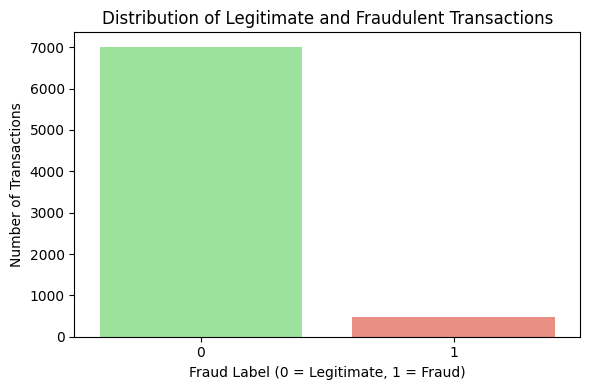

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(x="fraud_label", hue="fraud_label", data=df, palette=["lightgreen", "salmon"], legend=False)
plt.title("Distribution of Legitimate and Fraudulent Transactions")
plt.xlabel("Fraud Label (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()


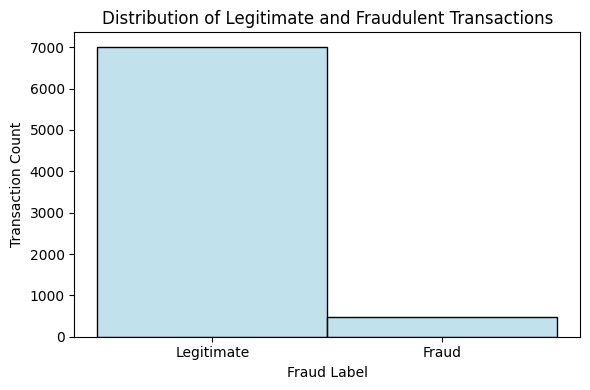

In [6]:
plt.figure(figsize=(6,4))
sns.histplot(x="fraud_label", data=df, bins=[-0.5, 0.5, 1.5], kde=False, color="lightblue")
plt.title("Distribution of Legitimate and Fraudulent Transactions")
plt.xlabel("Fraud Label")
plt.ylabel("Transaction Count")
plt.xticks([0, 1], ["Legitimate", "Fraud"])
plt.tight_layout()
plt.show()


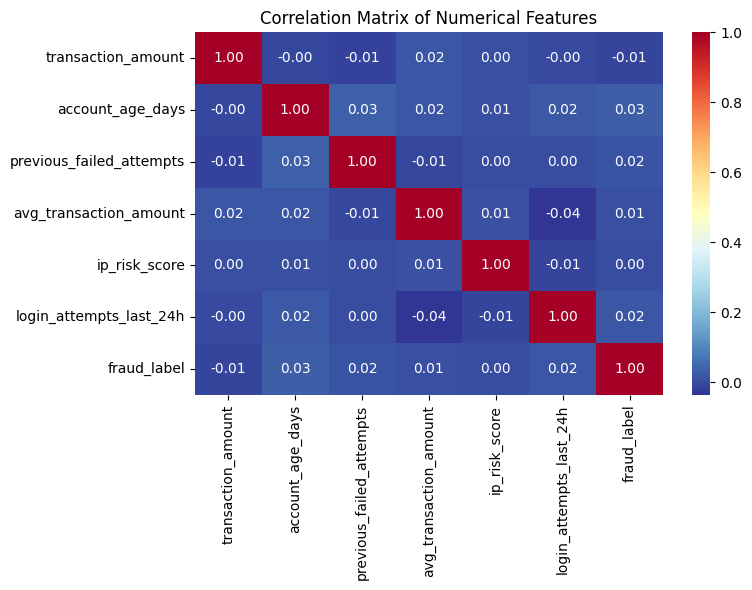

In [7]:
df2 = df[[
    "transaction_amount",
    "account_age_days",
    "previous_failed_attempts",
    "avg_transaction_amount",
    "ip_risk_score",
    "login_attempts_last_24h",
    "fraud_label"
]]
plt.figure(figsize=(8,6))
sns.heatmap(df2.corr(), annot=True, cmap="RdYlBu_r", fmt=".2f")
plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()


In [8]:
df.drop(columns=["transaction_id", "user_id"], inplace=True)

In [9]:
for col in df.select_dtypes(include=["object", "string"]).columns:
    label_encoder = preprocessing.LabelEncoder()
    label_encoder.fit(df[col].unique())
    df[col] = label_encoder.transform(df[col])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   transaction_amount        7500 non-null   float64
 1   transaction_type          7500 non-null   int64  
 2   payment_mode              7500 non-null   int64  
 3   device_type               7500 non-null   int64  
 4   device_location           7500 non-null   int64  
 5   account_age_days          7500 non-null   int64  
 6   transaction_hour          7500 non-null   int64  
 7   previous_failed_attempts  7500 non-null   int64  
 8   avg_transaction_amount    7500 non-null   float64
 9   is_international          7500 non-null   int64  
 10  ip_risk_score             7500 non-null   float64
 11  login_attempts_last_24h   7500 non-null   int64  
 12  fraud_label               7500 non-null   int64  
dtypes: float64(3), int64(10)
memory usage: 761.8 KB


In [10]:
X = df.drop("fraud_label", axis=1)
Y = df["fraud_label"]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)

Class distribution before SMOTE: Counter({0: 5609, 1: 391})
Class distribution after SMOTE: Counter({0: 5609, 1: 5609})


<Axes: xlabel='fraud_label', ylabel='count'>

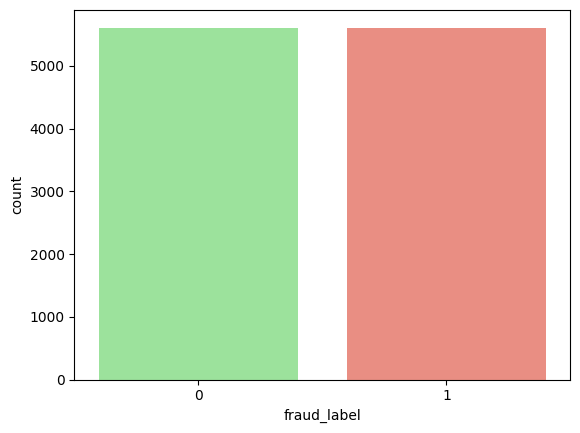

In [12]:
print(f'Class distribution before SMOTE: {Counter(y_train)}')
sm = SMOTE(random_state=42)
X_train_smote, y_train_smote = sm.fit_resample(X_train, y_train)
print(f'Class distribution after SMOTE: {Counter(y_train_smote)}')
sns.countplot(x=y_train_smote, hue=y_train_smote, palette=["lightgreen", "salmon"], legend=False)


In [13]:
model = LogisticRegression(random_state=42, max_iter=15000)
model.fit(X_train_smote, y_train_smote)
y_pred = model.predict(X_test)
accuracy_lr = accuracy_score(y_test, y_pred)
print("Accuracy – Logistic Regression:", accuracy_lr)

Accuracy – Logistic Regression: 0.646


In [14]:
dt_gini = DecisionTreeClassifier(random_state=42)
dt_gini.fit(X_train_smote, y_train_smote)
y_pred_gini = dt_gini.predict(X_test)
accuracy_gini = accuracy_score(y_test, y_pred_gini)
print("Accuracy – Decision Tree:", accuracy_gini)

Accuracy – Decision Tree: 0.7706666666666667


In [15]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_smote, y_train_smote)
rf_pred = rf.predict(X_test)
accuracy_rf = accuracy_score(y_test, rf_pred)
print("Accuracy – Random Forest:", accuracy_rf)

Accuracy – Random Forest: 0.856


In [16]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    use_label_encoder=False
)
xgb.fit(X_train_smote, y_train_smote)
xgb_pred = xgb.predict(X_test)
accuracy_xgb = accuracy_score(y_test, xgb_pred)
print("Accuracy – XGBoost:", accuracy_xgb)


Accuracy – XGBoost: 0.854


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:08:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [17]:
print("\nLogistic Regression Report:")
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

print("\nDecision Tree Report:")
print(classification_report(y_test, y_pred_gini))
print(confusion_matrix(y_test, y_pred_gini))

print("\nRandom Forest Report:")
print(classification_report(y_test, rf_pred))
print(confusion_matrix(y_test, rf_pred))

print("\nRandom XGBOOST Report:")
print(classification_report(y_test, xgb_pred))
print(confusion_matrix(y_test, xgb_pred))


Logistic Regression Report:
              precision    recall  f1-score   support

           0       0.94      0.67      0.78      1402
           1       0.07      0.34      0.11        98

    accuracy                           0.65      1500
   macro avg       0.50      0.50      0.44      1500
weighted avg       0.88      0.65      0.74      1500

[[936 466]
 [ 65  33]]

Decision Tree Report:
              precision    recall  f1-score   support

           0       0.93      0.81      0.87      1402
           1       0.06      0.16      0.09        98

    accuracy                           0.77      1500
   macro avg       0.50      0.49      0.48      1500
weighted avg       0.88      0.77      0.82      1500

[[1140  262]
 [  82   16]]

Random Forest Report:
              precision    recall  f1-score   support

           0       0.93      0.91      0.92      1402
           1       0.06      0.08      0.07        98

    accuracy                           0.86      1500
   

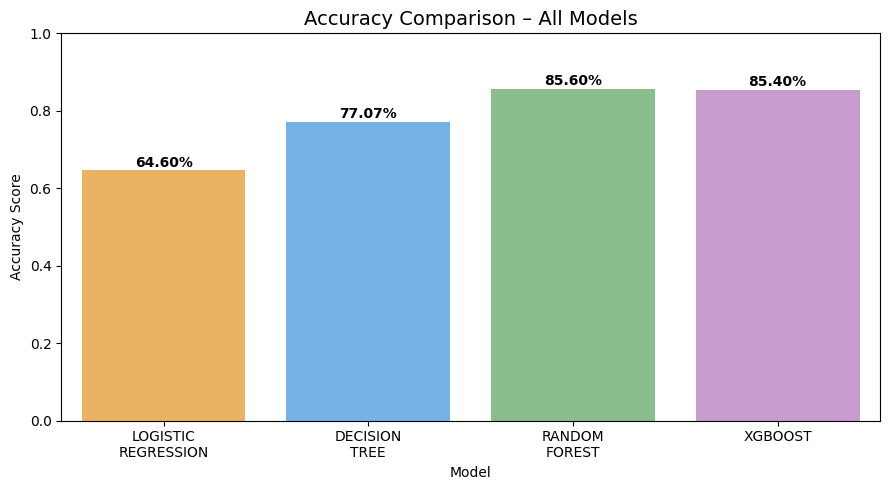

In [18]:
model_names_4 = ["LOGISTIC\nREGRESSION", "DECISION\nTREE", "RANDOM\nFOREST", "XGBOOST"]
model_accuracies_4 = [accuracy_lr, accuracy_gini, accuracy_rf, accuracy_xgb]

plt.figure(figsize=(9, 5))
bars = sns.barplot(
    x=model_names_4,
    y=model_accuracies_4,
    hue=model_names_4,
    palette=["#FFB74D", "#64B5F6", "#81C784", "#CE93D8"],
    legend=False
)

plt.title("Accuracy Comparison – All Models", fontsize=14)
plt.xlabel("Model")
plt.ylabel("Accuracy Score")
plt.ylim(0, 1)

for i, v in enumerate(model_accuracies_4):
    plt.text(i, v + 0.01, f"{v:.2%}", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

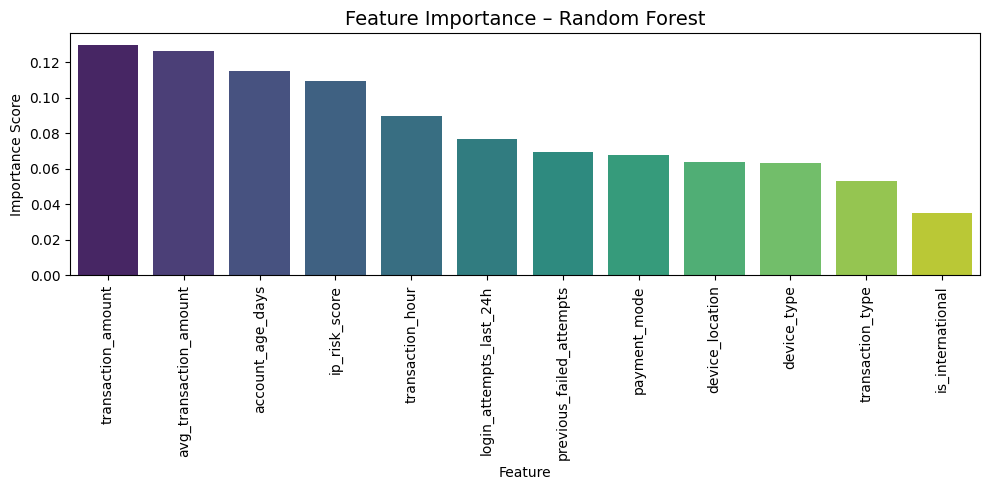


Feature Importance Ranking:
   1. transaction_amount             0.1297
   2. avg_transaction_amount         0.1263
   3. account_age_days               0.1152
   4. ip_risk_score                  0.1096
   5. transaction_hour               0.0895
   6. login_attempts_last_24h        0.0765
   7. previous_failed_attempts       0.0694
   8. payment_mode                   0.0675
   9. device_location                0.0640
  10. device_type                    0.0635
  11. transaction_type               0.0534
  12. is_international               0.0351


In [19]:
feature_names = X.columns.tolist()
importances   = rf.feature_importances_
indices       = np.argsort(importances)[::-1]
plt.figure(figsize=(10, 5))
sns.barplot(
    x=[feature_names[i] for i in indices],
    y=importances[indices],
    hue=[feature_names[i] for i in indices],
    palette="viridis",
    legend=False
)

plt.title("Feature Importance – Random Forest", fontsize=14)
plt.xlabel("Feature")
plt.ylabel("Importance Score")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print("\nFeature Importance Ranking:")
for rank, i in enumerate(indices, 1):
    print(f"  {rank:2}. {feature_names[i]:<30} {importances[i]:.4f}")